In [1]:
import pandas as pd

df = pd.read_csv("DataSet (1).csv")

print(df.shape)

(9082, 3925)


In [2]:
df

,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9077,9078,0.5,NaN,0.5,0.5,NaN,0.5,NaN,NaN,NaN,...,0,1,0,0,1,1,0,0,0,1
9078,9079,1.0,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,1
9079,9080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,1,0,0,0,1
9080,9081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,1


In [3]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [4]:
print(df.shape)

(9082, 3924)


In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

F3776    9082
F3773    9082
F3668    9082
F3665    9082
F542     9082
         ... 
F1547       2
F1546       2
F1545       2
F1544       2
F1543       2
Length: 3835, dtype: int64


In [6]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = df.select_dtypes(
    include=['object']
).columns

print(len(num_cols))
print(len(cat_cols))

3916
8


In [7]:
df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

In [8]:
for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [9]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(
        df[col].astype(str)
    )
    
    encoders[col] = le

In [10]:
X = df.drop("F3924", axis=1)

y = df["F3924"]

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [13]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(
    ascending=False
).head(100)

print(top_features)

F3912    0.071018
F2230    0.042414
F3805    0.010936
F3811    0.008324
F3806    0.008117
           ...   
F3838    0.001495
F3606    0.001484
F119     0.001481
F3059    0.001464
F3239    0.001457
Length: 100, dtype: float64


In [14]:
selected_features = top_features.index.tolist()

X = X[selected_features]

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train,y_train = smote.fit_resample(
    X_train,
    y_train
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
from sklearn.metrics import classification_report

pred = xgb.predict(
    X_test
)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817



In [21]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


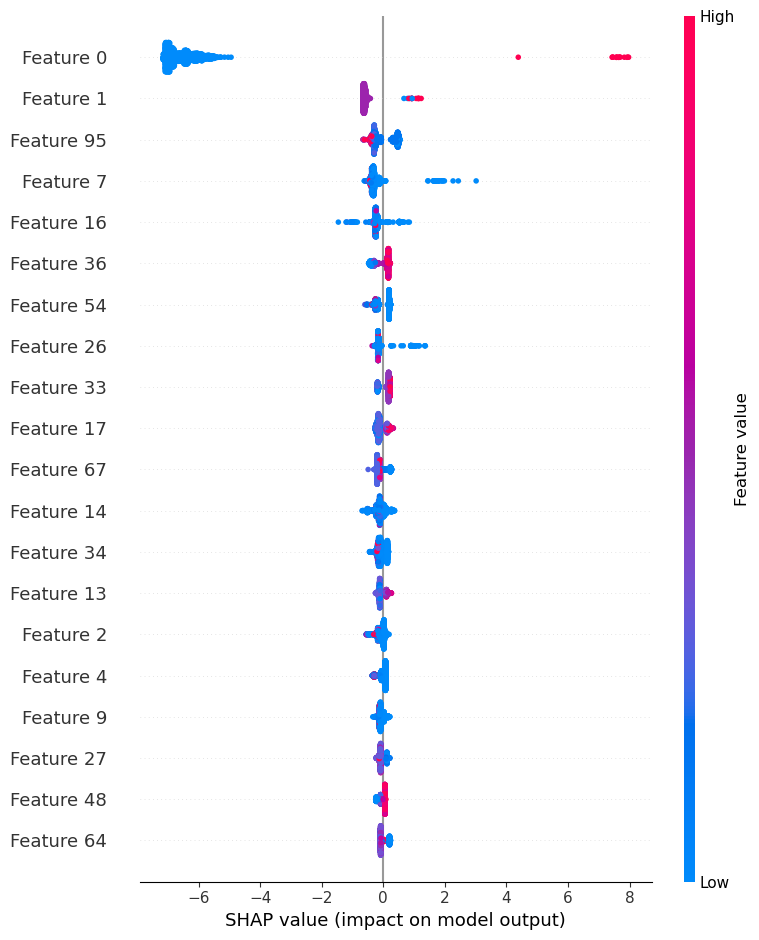

In [22]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [23]:
import joblib

joblib.dump(
    xgb,
    "fraud_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    selected_features,
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [24]:
print(df.isnull().sum().sum())

print(df.select_dtypes(include=['object']).columns)

print(df['F3924'].value_counts())

572166
Index([], dtype='object')
F3924
0    9001
1      81
Name: count, dtype: int64


In [25]:
print(model)

NameError: name 'model' is not defined

In [26]:
import os

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

feature_columns.pkl
fraud_model.pkl
scaler.pkl


In [27]:
import joblib

model = joblib.load("fraud_model.pkl")

print(type(model))
print(model)

<class 'xgboost.sklearn.XGBClassifier'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)


In [28]:
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>
